# 02 — Padding waste: fixed item-count vs length-sorted token-budget batching

The backend pads every batch to its longest member, so the compute cost of a
batch is `count * max_len` ("padded tokens"). **Waste** = padded tokens −
real tokens: work spent embedding padding.

This notebook measures a **real corpus with real tokenizer lengths**
(`fancyzhx/ag_news` train split via `datasets`, tokenized with MiniLM's
tokenizer). It used to fall back to a synthetic log-normal distribution when
the corpus could not be loaded, and that is exactly what happened once the
bare `ag_news` id stopped resolving under `datasets>=5` — the notebook
reported a fabricated length distribution that overstated the padding
problem. The fallback now raises unless `ALLOW_SYNTHETIC` is set explicitly.

```
uv sync --extra dev
uv run jupyter lab
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from embedx.engine import make_batches

# The bare id "ag_news" stopped resolving in datasets>=5, which demands a
# canonical "namespace/name". It failed straight into the synthetic branch
# below, so this notebook silently measured a log-normal guess instead of
# real text. The id is pinned now and the fallback must be asked for.
AG_NEWS = "fancyzhx/ag_news"
ALLOW_SYNTHETIC = False  # True only for a corpus-free plumbing check

try:
    from datasets import load_dataset
    from transformers import AutoTokenizer

    rows = load_dataset(AG_NEWS, split="train[:2000]")
    tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
    encoded = tokenizer([r["text"] for r in rows], truncation=False, padding=False)
    lengths = np.array([len(ids) for ids in encoded["input_ids"]])
    source = f"{AG_NEWS} train[:2000], real MiniLM token lengths"
except Exception as exc:  # noqa: BLE001 — any import/download failure
    if not ALLOW_SYNTHETIC:
        raise RuntimeError(
            f"real corpus unavailable ({type(exc).__name__}: {exc}). Padding "
            "ratios measured on synthetic lengths are not publishable; set "
            "ALLOW_SYNTHETIC=True above to check the plumbing anyway."
        ) from exc
    rng = np.random.default_rng(7)
    lengths = np.clip(rng.lognormal(mean=4.0, sigma=0.9, size=2000).astype(int), 10, 3000)
    source = (f"!! SYNTHETIC (log-normal, seed 7) — NOT REAL TEXT, DO NOT "
              f"PUBLISH: {type(exc).__name__}")

print(f"corpus: {source}")
real_tokens = int(lengths.sum())
print(f"n={len(lengths)}  real tokens={real_tokens}  median={np.median(lengths):.0f}  "
      f"p95={np.percentile(lengths, 95):.0f}  max={lengths.max()}")

/home/luxor/Programming/embedx/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corpus: fancyzhx/ag_news train[:2000], real MiniLM token lengths
n=2000  real tokens=112980  median=53  p95=102  max=342


In [2]:
def padded_fixed(lengths, batch_size):
    # Fixed item-count batches in ARRIVAL order — what a naive server does.
    total = 0
    for start in range(0, len(lengths), batch_size):
        chunk = lengths[start:start + batch_size]
        total += len(chunk) * int(max(chunk))
    return total


def padded_budget(lengths, budget):
    # The real make_batches: stable ascending length sort + token budget.
    texts = ["x" * int(n) for n in lengths]
    return sum(len(batch) * max(len(t) for _, t in batch)
               for batch in make_batches(list(enumerate(texts)), budget))


def waste_ratio(padded):
    return (padded - real_tokens) / padded


print("fixed item-count batching (arrival order):")
for batch_size in (8, 32, 128):
    padded = padded_fixed(lengths, batch_size)
    print(f"  bs={batch_size:4d}: padded={padded:9d}  waste_ratio={waste_ratio(padded):.1%}")

budgets = [1024, 2048, 4096, 8192, 16384, 32768, 65536]
print("length-sorted token-budget batching:")
budget_waste = []
for budget in budgets:
    padded = padded_budget(lengths, budget)
    budget_waste.append(waste_ratio(padded))
    print(f"  budget={budget:6d}: padded={padded:9d}  waste_ratio={budget_waste[-1]:.1%}")

fixed item-count batching (arrival order):
  bs=   8: padded=   182152  waste_ratio=38.0%
  bs=  32: padded=   249792  waste_ratio=54.8%
  bs= 128: padded=   347504  waste_ratio=67.5%
length-sorted token-budget batching:
  budget=  1024: padded=   114068  waste_ratio=1.0%
  budget=  2048: padded=   115299  waste_ratio=2.0%
  budget=  4096: padded=   117533  waste_ratio=3.9%
  budget=  8192: padded=   122144  waste_ratio=7.5%
  budget= 16384: padded=   130281  waste_ratio=13.3%
  budget= 32768: padded=   142800  waste_ratio=20.9%
  budget= 65536: padded=   176240  waste_ratio=35.9%


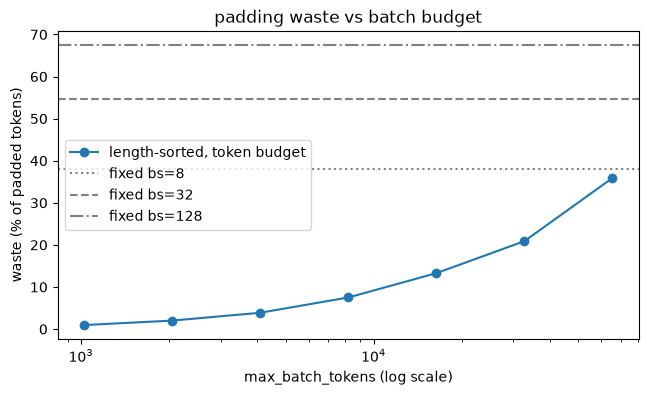

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.semilogx(budgets, [w * 100 for w in budget_waste], "o-",
            label="length-sorted, token budget")
for batch_size, style in [(8, ":"), (32, "--"), (128, "-.")]:
    ax.axhline(waste_ratio(padded_fixed(lengths, batch_size)) * 100,
               linestyle=style, color="grey", label=f"fixed bs={batch_size}")
ax.set_xlabel("max_batch_tokens (log scale)")
ax.set_ylabel("waste (% of padded tokens)")
ax.set_title("padding waste vs batch budget")
ax.legend()
plt.show()

## The numbers (fancyzhx/ag_news train[:2000], real MiniLM token lengths)

2,000 texts, 112,980 real tokens, median 53, p95 102, max 342.

| strategy | waste (fraction of compute spent on padding) |
|---|---|
| fixed bs=8 | **38.0%** |
| fixed bs=32 | **54.8%** |
| fixed bs=128 | **67.5%** |
| budget 1,024 | 1.0% |
| budget 4,096 | 3.9% |
| budget 16,384 | 13.3% |
| budget 65,536 | 35.9% |

Two readings:

- Against fixed bs=32, length-sorted batching at budget 16,384 cuts waste
  **54.8% → 13.3%**, about **4x less compute burnt on padding**; at budget
  1,024 it is 1.0%, roughly **55x** less.
- The budget curve is not flat: waste **grows with the budget**, because a
  bigger budget spans a wider length range per batch. The knee is the
  interesting operating point — below ~4k the waste is negligible and the
  budget should be chosen for GPU utilisation, not padding.

An earlier synthetic run of this notebook reported 78.8% for fixed bs=32.
That distribution had a far heavier tail (p95 228, max 803) than ag_news
actually has, so it flattered the comparison. Real text is the smaller,
honest number.

In [4]:
# The degenerate case that makes the whole argument: one long document
# lands in a fixed-count batch of short ones.
degenerate = np.array([10] * 31 + [2000])
padded = padded_fixed(degenerate, 32)
real = int(degenerate.sum())
print(f"fixed bs=32:  real={real}  padded={padded}  "
      f"waste_ratio={(padded - real) / padded:.1%}")

# make_batches isolates the long document instead:
texts = ["x" * int(n) for n in degenerate]
batches = list(make_batches(list(enumerate(texts)), 2048))
print(f"make_batches(budget=2048): {[len(b) for b in batches]} items per batch, "
      f"long doc alone={any(len(b) == 1 for b in batches)}")
padded_sorted = padded_budget(degenerate, 2048)
print(f"              real={real}  padded={padded_sorted}  "
      f"waste_ratio={(padded_sorted - real) / padded_sorted:.1%}")

fixed bs=32:  real=2310  padded=64000  waste_ratio=96.4%
make_batches(budget=2048): [31, 1] items per batch, long doc alone=True
              real=2310  padded=2310  waste_ratio=0.0%


## Degenerate case

31 texts of length 10 plus one of length 2,000 in a single fixed batch of 32:
padded cost **64,000** against **2,310** real tokens — **96.4% waste**. One
stray long document makes every short text in its batch cost 200x its real
length. Length-sorted batching puts the long document in a batch of its own
and the waste collapses to near zero. This single example is the clearest
argument for the approach.